**<span style="font-size:18px">Video Game Sales Analysis: Finding Successful Strategies for 2017</span>**

<span style="font-size:16px">The gaming industry is developing rapidly, and many new games are released every year. However, not all of them become popular and profitable. To understand which games will sell well, it is necessary to study what influences their success: genres, platforms, critic and user reviews, as well as player preferences in different regions.</span>

<span style="font-size:16px">In this project, we will study game sales data up to 2016 to determine which games and platforms were the most successful, and use this information to plan game releases in 2017.</span>

**<span style="font-size:24px">Step 1. Opening the data file and examining the general information</span>**

In [154]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

In [155]:
data = pd.read_csv('games.csv')
data.head(10)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


In [156]:
data.isna().sum()

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64

In [157]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


<span style="font-size:16px; color:red">There are missing values, incorrect column names, and data types that need to be processed before starting the exploratory data analysis.</span>

**<span style="font-size:24px">Step 2. Preparing the data</span>**

In [158]:
data.columns = data.columns.str.lower()

<span style="font-size:18px">Filling in the missing values</span>

In [159]:
columns = ['year_of_release', 'name', 'genre']

for column in columns:
    print(data[column].isna().sum() / data.shape[0])

0.01609332934489979
0.00011965300628178283
0.00011965300628178283


In [160]:
for column in columns:
    data = data.dropna(subset=[column])

<span style="font-size:16px">We will leave the missing values in the user_score and critic_score columns as they are, since replacing them with the median, mean, or a placeholder number would affect hypothesis testing. Also, notice the 'tbd' value in the user_score column. TBD stands for "To Be Determined"—meaning the score will be determined later. Semantically, this is no different from a missing value. We will replace only the 'tbd' values with NaN in order to give the column a numeric type and calculate averages.</span>

In [161]:
data['user_score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

In [162]:
data['user_score'] = data['user_score'].replace('tbd', np.nan)

<span style="font-size:16px">In the rating column, replace missing values with 'unknown'.</span>

In [163]:
data['rating'] = data['rating'].fillna('unknown')

In [164]:
data.isnull().sum()

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8461
user_score         8981
rating                0
dtype: int64

**Possible causes of missing values:**

- Release year: Missing values are most likely related to unspecified or unavailable game release date information. These could be either old, obscure projects or errors in the database export.


- User score and Critic score: Not all games receive critic and user scores. This is especially common for unpopular games, old games, or new releases that do not have reviews yet.


- ESRB rating: The ESRB rating is primarily assigned for the US market. Many Japanese or European games do not receive it. Additionally, a rating is not assigned if the game has not gone through certification.


- Name and Genre: Most likely, these are database errors—rows without a title and genre are of no use.


**<span style="font-size:16px; color:green">Missing values are filled.</span>**

<span style="font-size:18px">Changing data types</span>

In [165]:
data['year_of_release'] = data['year_of_release'].astype(int)

In [166]:
data['user_score'] = pd.to_numeric(data['user_score'], errors='coerce')

In [167]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  int32  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           16444 non-null  object 
dtypes: float64(6), int32(1), object(4)
memory usage: 1.4+ MB


**<span style="font-size:16px; color:green">Data types are changed.</span>**

In [168]:
data['total_sales'] = data['na_sales'] + data['eu_sales'] + data['jp_sales'] + data['other_sales']

In [169]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16444 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  int32  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           16444 non-null  object 
 11  total_sales      16444 non-null  float64
dtypes: float64(7), int32(1), object(4)
memory usage: 1.6+ MB


In [170]:
data.isna().sum()

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8461
user_score         8981
rating                0
total_sales           0
dtype: int64

Let's check the data for explicit and implicit duplicates.

In [171]:
data.duplicated().sum()

0

**No explicit duplicates were found.**

In [172]:
data[data[['name', 'platform','year_of_release']].duplicated(keep=False)]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
604,Madden NFL 13,PS3,2012,Sports,2.11,0.22,0.0,0.23,83.0,5.5,E,2.56
16230,Madden NFL 13,PS3,2012,Sports,0.00,0.01,0.0,0.00,83.0,5.5,E,0.01


During the check, implicit duplicates were found—rows with identical values in the key columns (name, platform, year_of_release), but with differing sales data. Such cases usually occur when merging data from different sources or due to recording errors. Only the sales data differs, so deleting the second row will not affect the overall picture.

In [173]:
data = data.drop(index=16230)

**<span style="font-size:16px; color:green">Data successfully cleaned: columns were converted to the correct types, missing values were filled where possible, column names were standardized, and duplicates—both explicit and implicit—were removed. The data is ready for further analysis.</span>**

**<span style="font-size:24px">Step 3. Performing exploratory data analysis</span>**

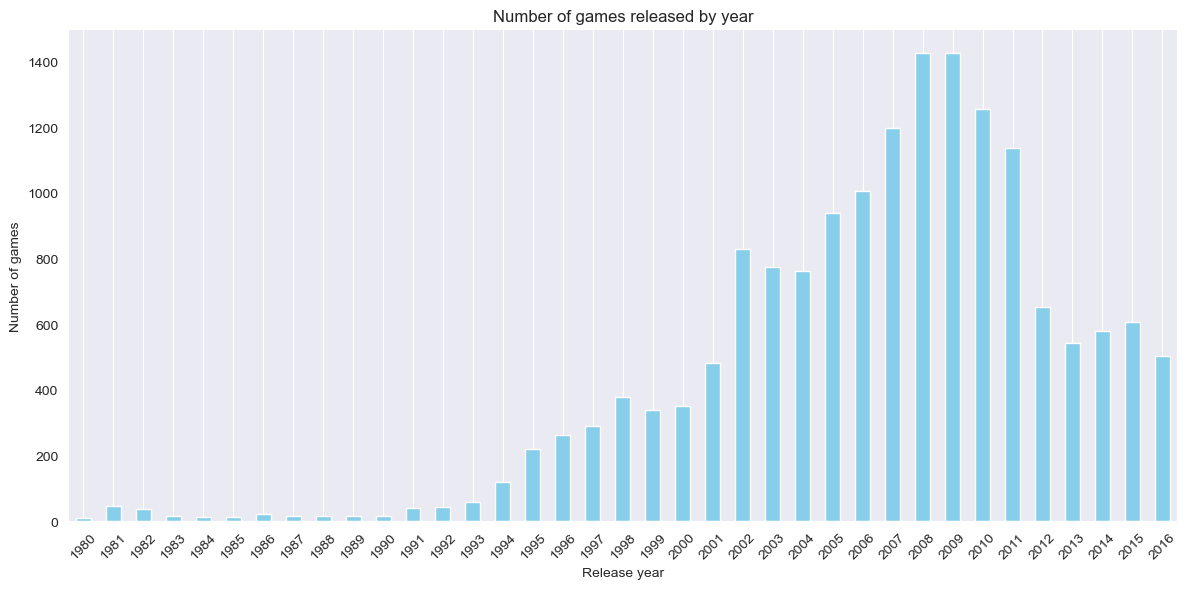

In [174]:

games_per_year = data.groupby('year_of_release')['name'].count()
plt.figure(figsize=(12,6))
games_per_year.plot(kind='bar', color='skyblue')
plt.title('Number of games released by year')
plt.xlabel('Release year')
plt.ylabel('Number of games')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

- **Before 1995, there is very little data—it may be incomplete or irrelevant.**


- **Active growth has been observed since the 2000s.**


- **The peak in releases occurs around 2008–2010.**

C:\Users\nelli\AppData\Local\Temp\ipykernel_16388\3868886351.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=platform_sales_total.index, y=platform_sales_total.values, palette='viridis')


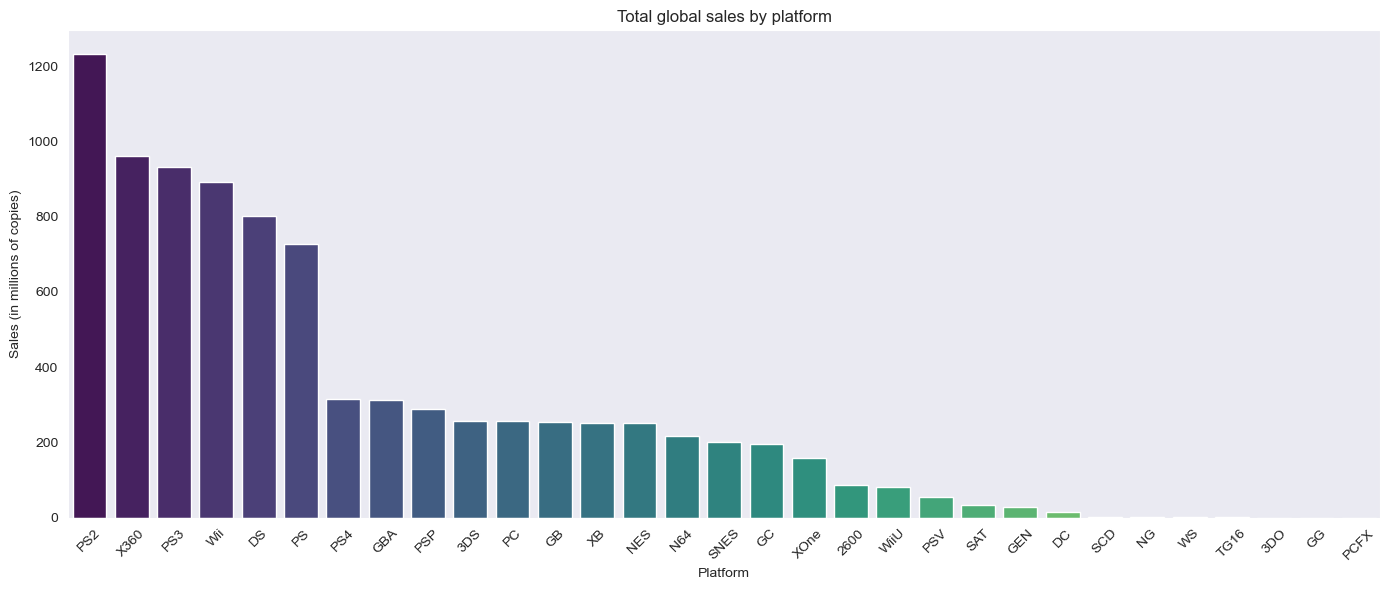

In [175]:

platform_sales_total = (
    data.groupby('platform')['total_sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 6))
sns.barplot(x=platform_sales_total.index, y=platform_sales_total.values, palette='viridis')
plt.title('Total global sales by platform')
plt.xlabel('Platform')
plt.ylabel('Sales (in millions of copies)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


**Let's take the top 5 platforms with the maximum number of sold games and plot the distribution of sales by years for each of them. This will allow us to see the life cycle of a successful gaming platform.**

In [176]:

top_5_platforms = (
    data.groupby('platform')['total_sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)


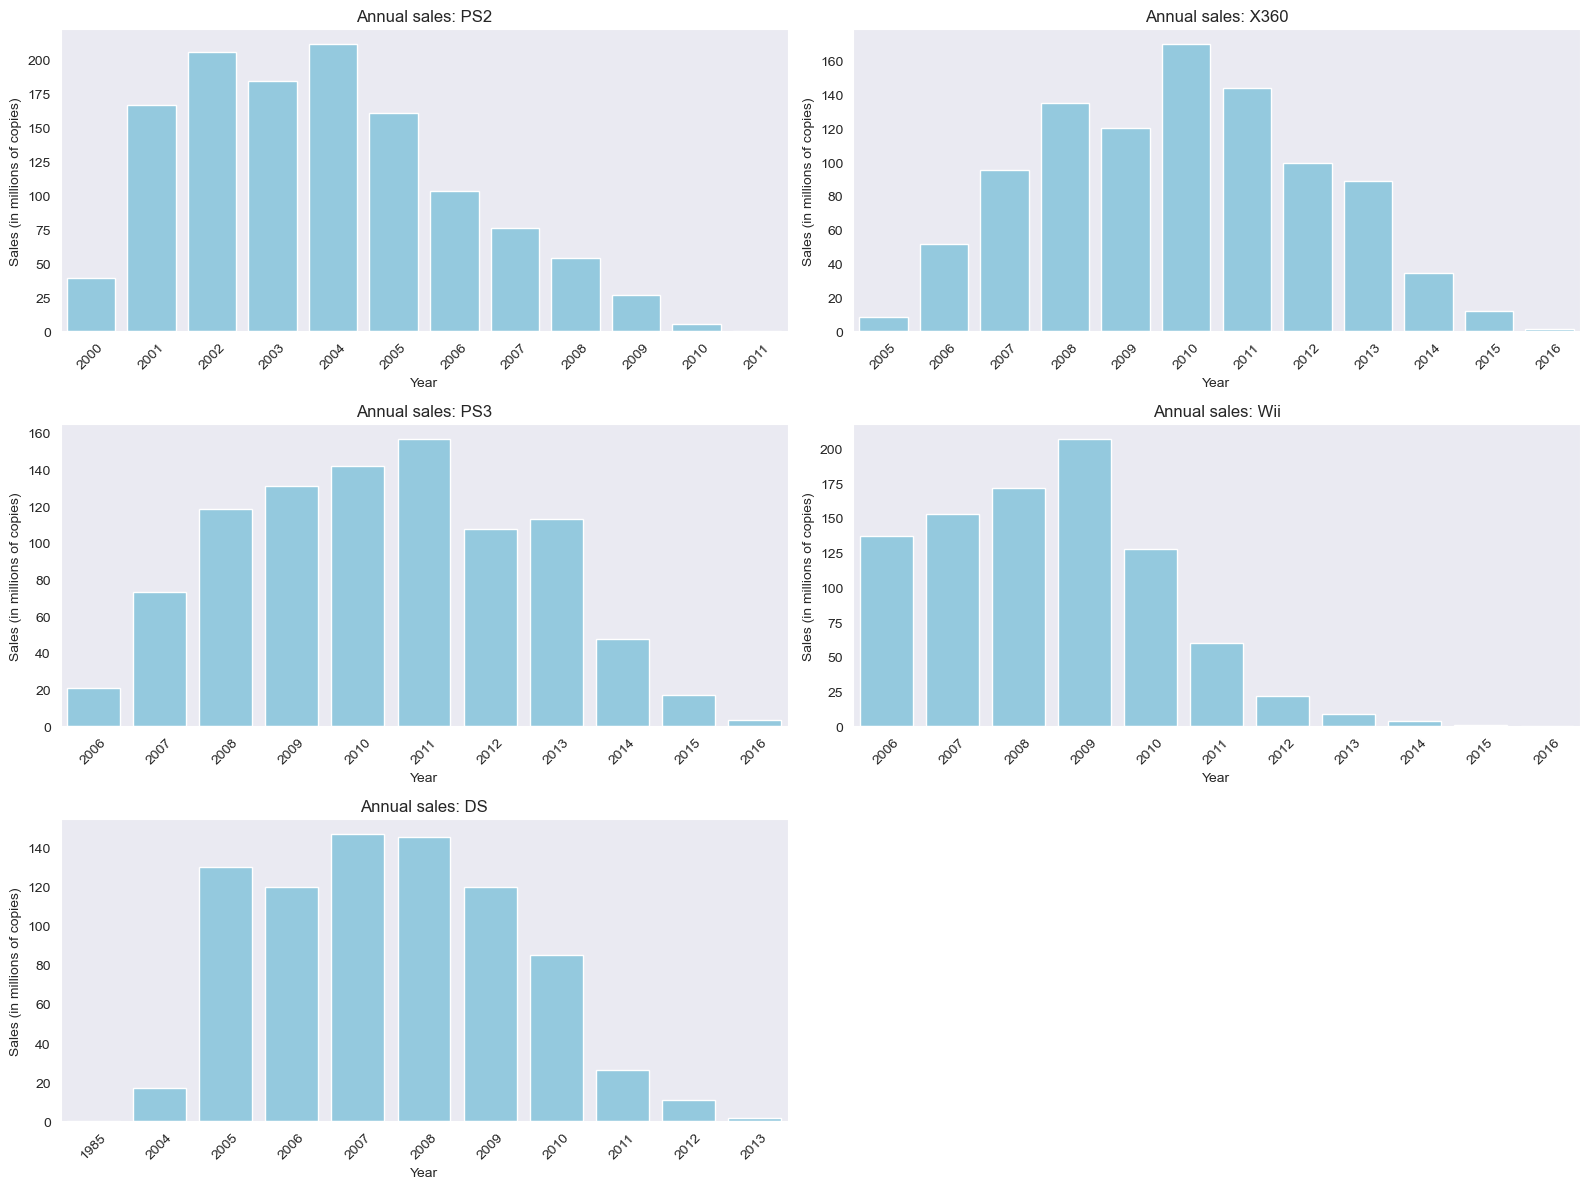

In [177]:

plt.figure(figsize=(16, 12))

for i, platform in enumerate(top_5_platforms, 1):
    plt.subplot(3, 2, i)
    platform_data = (
        data[data['platform'] == platform]
        .groupby('year_of_release')['total_sales']
        .sum()
        .reset_index()
    )

    sns.barplot(data=platform_data, x='year_of_release', y='total_sales', color='skyblue')
    plt.title(f'Annual sales: {platform}')
    plt.xlabel('Year')
    plt.ylabel('Sales (in millions of copies)')
    plt.xticks(rotation=45)
    plt.grid(axis='y')

plt.tight_layout()
plt.show()

**<span style="color:green">The platform lifecycle is about 10 years.</span>**

Each platform follows a typical path:



- Launch — low sales;



- Growth — a sharp increase in popularity over 2–3 years;



- Decline — sales drop to zero approximately 8–10 years after launch.



**<span style="font-size:16px; color:green">Trends and preferences change rapidly. The gaming industry is developing dynamically—new platforms emerge, popular genres shift, and user preferences change. Fresh data over the last 3-5 years more accurately reflects current and future trends.</span>**

In [178]:
actual_data = data[data['year_of_release'].between(2013, 2016)]

In [179]:
actual_platform_sales_total = (
    actual_data.groupby('platform')['total_sales']
    .sum()
    .sort_values(ascending=False)
)

C:\Users\nelli\AppData\Local\Temp\ipykernel_16388\101123530.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


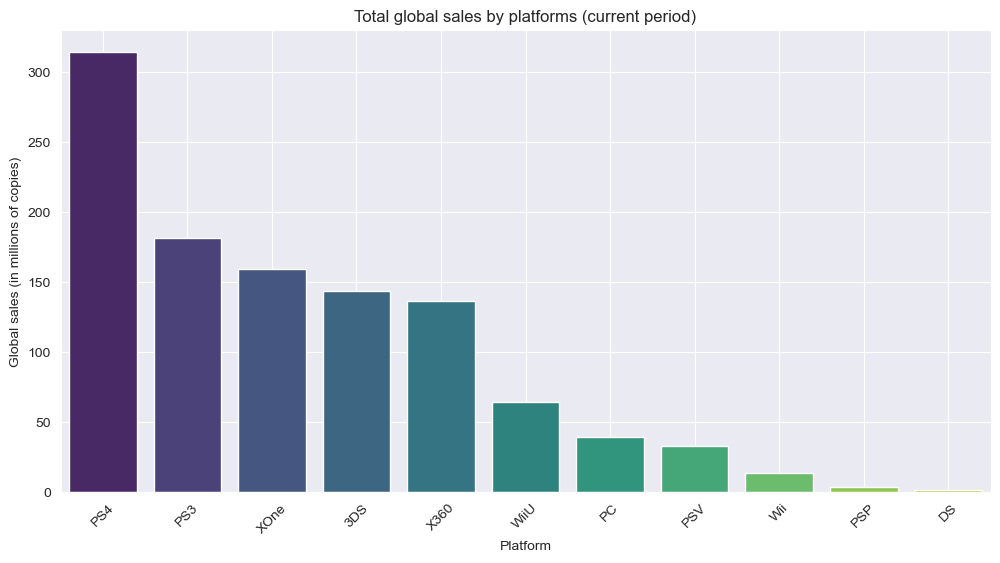

In [180]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x=actual_platform_sales_total.index,
    y=actual_platform_sales_total.values,
    palette='viridis'
)

plt.title('Total global sales by platforms (current period)')
plt.xlabel('Platform')
plt.ylabel('Global sales (in millions of copies)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Let's select the top 5 profitable platforms and create a box plot for global sales.

In [181]:
top_5_profitable_platforms = ['PS4', 'PS3', 'XOne', '3DS', 'X360']

C:\Users\nelli\AppData\Local\Temp\ipykernel_16388\1384242328.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=top_data, x='platform', y='total_sales', palette='Set2')


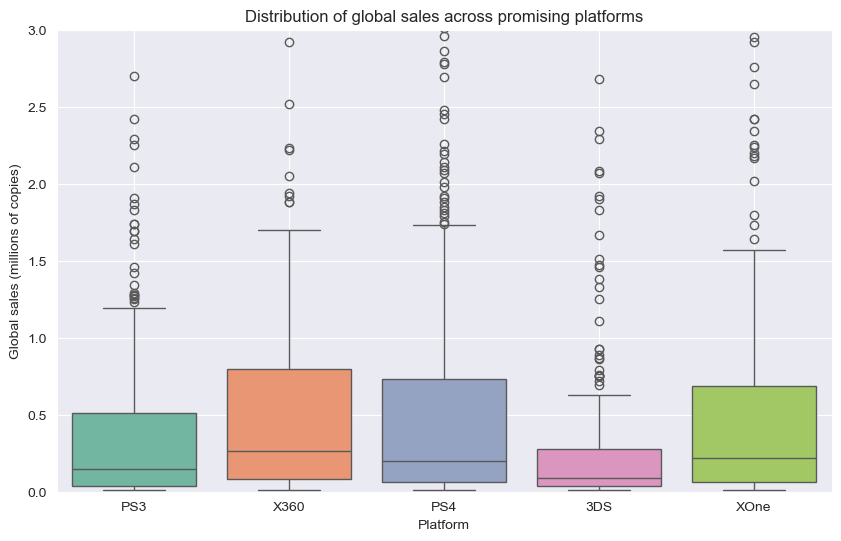

In [182]:
top_data = actual_data[actual_data['platform'].isin(top_5_profitable_platforms)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=top_data, x='platform', y='total_sales', palette='Set2')
plt.ylim(0, 3)
plt.title('Distribution of global sales across promising platforms')
plt.xlabel('Platform')
plt.ylabel('Global sales (millions of copies)')
plt.grid(True)
plt.show()

- **The highest median values belong to X360 and PS4—they are positioned higher than the others, indicating more consistent sales on these platforms.**


- **3DS has the lowest median, meaning most games sold worse there compared to other platforms.**


- **All platforms feature a significant number of outliers (points above the whiskers), indicating that there were games with exceptionally high sales.**


- **PS3, PS4, and 3DS have a particularly high number of outliers, pointing to the presence of major hits.**
 
 
**Conclusion:**

**<span style="font-size:16px; color:green">The X360 and PS4 platforms demonstrate the highest and most stable sales, making them particularly promising. </span>**


In [183]:
platform_name = 'PS4'
platform_data = actual_data[actual_data['platform'] == platform_name]

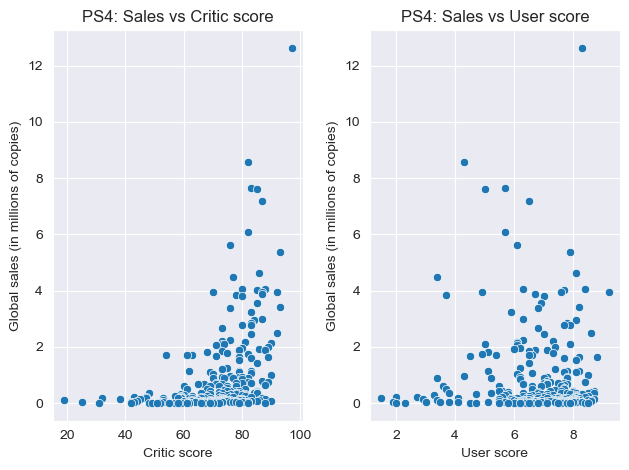

In [184]:

plt.subplot(1, 2, 1)
sns.scatterplot(data=platform_data, x='critic_score', y='total_sales')
plt.title(f'{platform_name}: Sales vs Critic score')
plt.xlabel('Critic score')
plt.ylabel('Global sales (in millions of copies)')

plt.subplot(1, 2, 2)
sns.scatterplot(data=platform_data, x='user_score', y='total_sales')
plt.title(f'{platform_name}: Sales vs User score')
plt.xlabel('User score')
plt.ylabel('Global sales (in millions of copies)')

plt.tight_layout()
plt.show()

**Left chart:**

Sales vs Critic score
- X-axis — critic scores (from ~30 to 100),
- Y-axis — global sales (in millions of copies).
- A positive correlation is observed: as critic scores increase, sales also grow. It is especially noticeable that games with a rating above 80 more often sell better—reaching 1–2 million copies or more.



**Right chart:**

Sales vs User score
- X-axis — user scores (from ~1 to 9),
- Y-axis — the same global sales (in millions of copies).
- The relationship is much weaker than with critic scores. Even with high user ratings, the majority of games have low sales. Individual "hits" are visible, but there is almost no overall dependency.



In [185]:
critic_corr = actual_data[actual_data['platform'] == platform_name]['critic_score'].corr(actual_data[actual_data['platform'] == platform_name]['total_sales'])
user_corr = actual_data[actual_data['platform'] == platform_name]['user_score'].corr(actual_data[actual_data['platform'] == platform_name]['total_sales'])

critic_corr, user_corr

(0.40656790206178123, -0.03195711020455644)

- On the PS4 platform, there is a moderate positive correlation between critic scores and global sales (approximately 0.40), indicating some influence of professional reviews on the commercial success of games.

- The correlation between user scores and sales is weaker (-0.03) and close to zero. This may be because user reviews are often subjective or left after the purchase has already been made.

**Conclusion:**

 **<span style="font-size:16px; color:green">Critic scores predict PS4 game sales better than user scores. This may suggest that professional reviews play a more important role in the purchasing decision.</span>**


Let's check this relationship across multiple platforms. A pattern found on only a single platform could be coincidental and might not hold true elsewhere. Conversely, if a similar correlation between scores and sales is observed across several platforms, we can draw much more reliable conclusions.

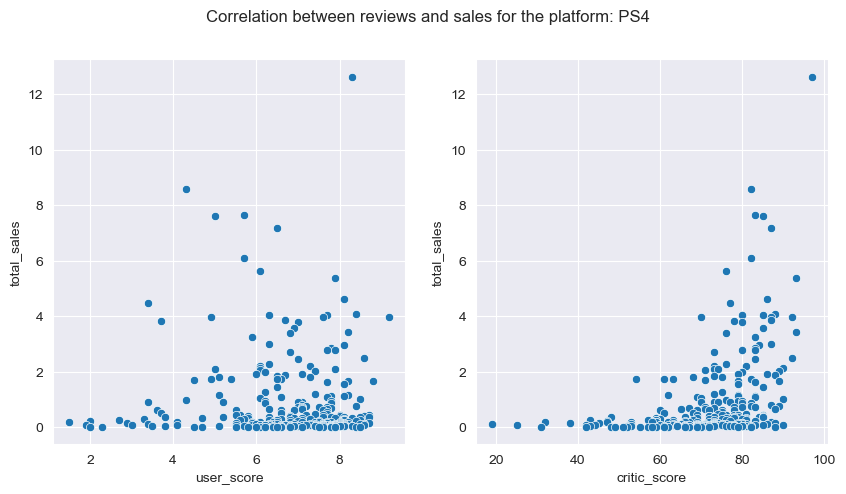

Correlation between critic reviews and sales for the platform: 0.40656790206178123
Correlation between user reviews and sales for the platform: -0.03195711020455643


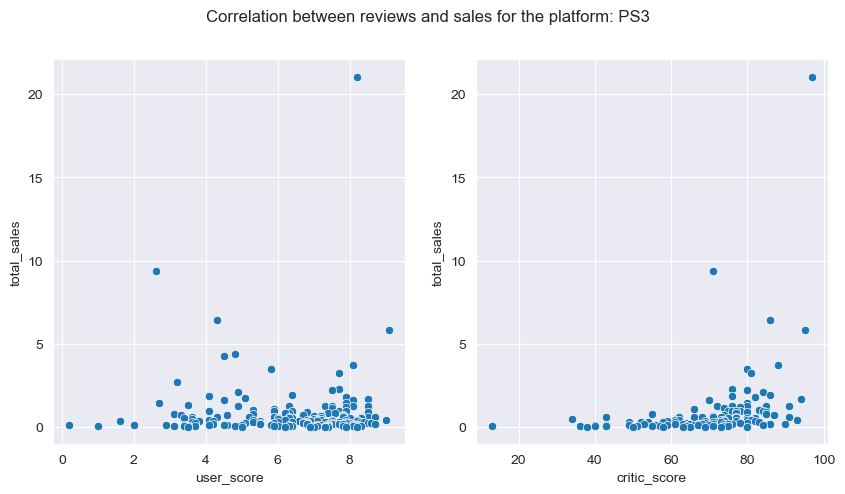

Correlation between critic reviews and sales for the platform: 0.33428533933719184
Correlation between user reviews and sales for the platform: 0.0023944027357567033


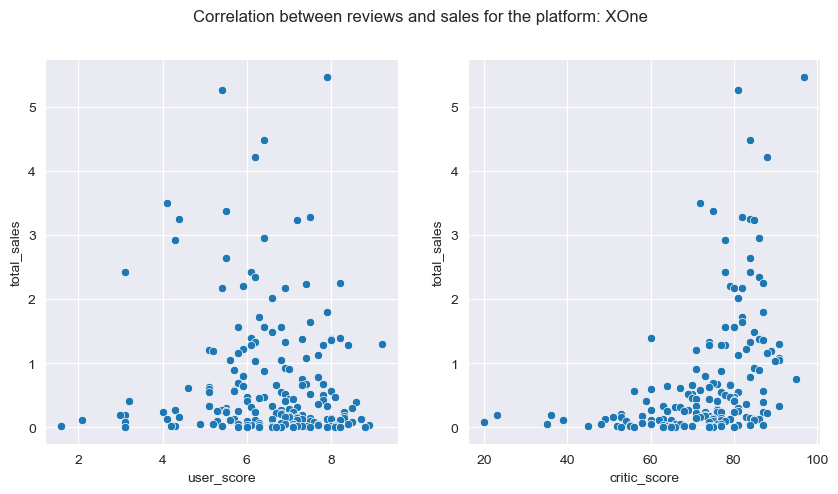

Correlation between critic reviews and sales for the platform: 0.41699832800840153
Correlation between user reviews and sales for the platform: -0.06892505328279418


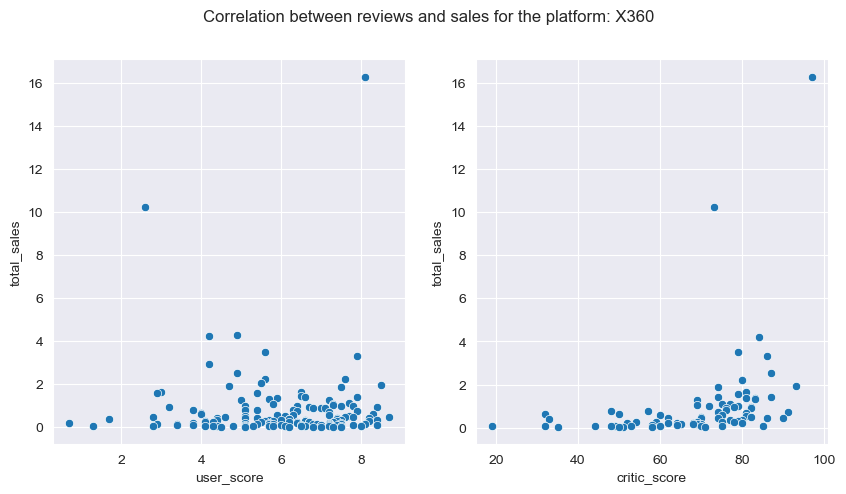

Correlation between critic reviews and sales for the platform: 0.3503445460228664
Correlation between user reviews and sales for the platform: -0.011742185147181334


In [186]:
def plot_corr(data, platform):
    scores = actual_data[['platform', 'critic_score', 'user_score', 'total_sales']].query('platform == @platform')
    
    fig, axes = plt.subplots(1, 2, figsize=(10,5))
    fig.suptitle(f"Correlation between reviews and sales for the platform: {platform}")
    for i, score in enumerate(['user_score', 'critic_score']):
        sns.scatterplot(ax=axes[i], data=scores, x=score, y='total_sales')
    plt.show()

    print ('Correlation between critic reviews and sales for the platform:', scores['total_sales'].corr(scores['critic_score']))
    print('Correlation between user reviews and sales for the platform:', scores['total_sales'].corr(scores['user_score']))

platforms = ['PS4', 'PS3', 'XOne', 'X360']
for platform in platforms:
    plot_corr(actual_data, platform)

**<span style="font-size:16px; color:green">The conclusion is identical—checking multiple platforms confirms that professional reviews play a more important role in the purchasing decision.</span>**


Let's build the overall distribution of games by genre and identify the genres with the highest profit and sales volume.

In [187]:
genre_counts = (
    actual_data
    .groupby('genre')['name']
    .count()
    .reset_index()
    .rename(columns={'name': 'game_count'})
)


total_games = genre_counts['game_count'].sum()
genre_counts['fraction'] = (genre_counts['game_count'] / total_games).round(3)

In [188]:
genre_sales = (
    actual_data
    .groupby('genre')['total_sales']
    .sum()
    .sort_values(ascending=False)
)

genre_sales = genre_sales.reset_index()
genre_sales.columns = ['genre', 'total_sales']


In [189]:


genre_summary = pd.merge(genre_sales, genre_counts, on='genre')
genre_summary.sort_values(by='total_sales', ascending=False).reset_index(drop=True)

,genre,total_sales,game_count,fraction
0,Action,321.87,766,0.343
1,Shooter,232.98,187,0.084
2,Sports,150.65,214,0.096
3,Role-Playing,145.89,292,0.131
4,Misc,62.82,155,0.069
5,Platform,42.63,74,0.033
6,Racing,39.89,85,0.038
7,Fighting,35.31,80,0.036
8,Adventure,23.64,245,0.110
9,Simulation,21.76,62,0.028


**<span style="color:green">As a result, we get a summary table showing the genre names, total sales, number of games sold (or releases), and their share of total sales.</span>**

C:\Users\nelli\AppData\Local\Temp\ipykernel_16388\414380539.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=actual_data, x='genre', y='total_sales', palette='Set2')


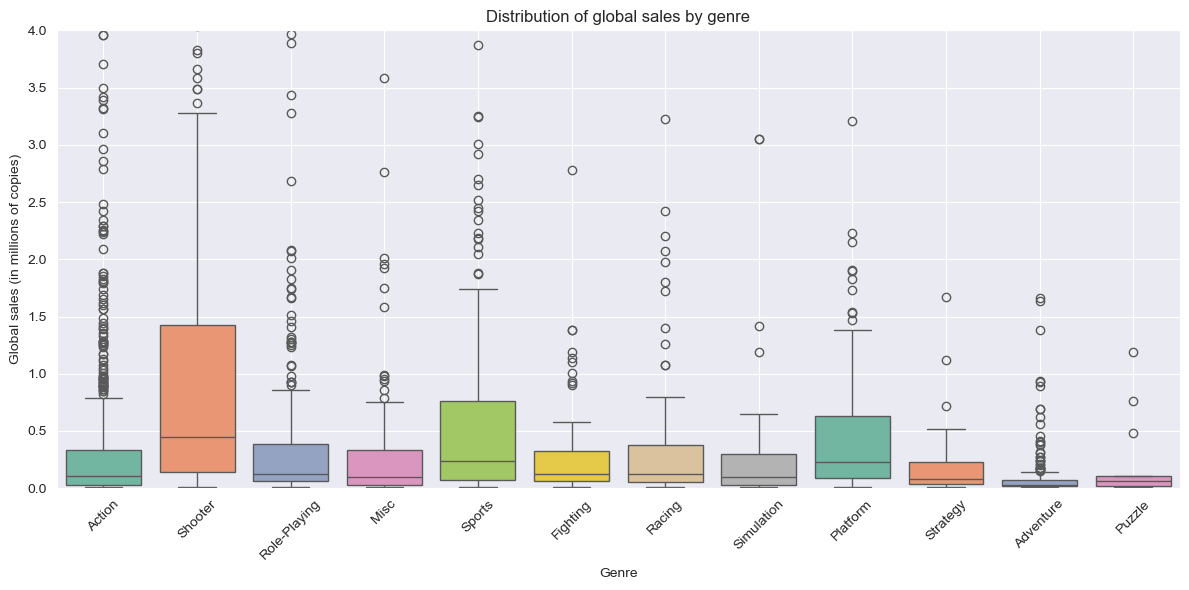

In [190]:

plt.figure(figsize=(12, 6))
sns.boxplot(data=actual_data, x='genre', y='total_sales', palette='Set2')
plt.title('Distribution of global sales by genre')
plt.ylabel('Global sales (in millions of copies)')
plt.xlabel('Genre')
plt.ylim(0, 4)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


**Shooter and Sports are among the most profitable genres:**
- They have high median sales as well as many upper outliers, indicating consistent sales for the majority of titles alongside hits with exceptionally high results.



**Action — slightly lower median, but consistently popular:**
- Features many games with moderate sales and plenty of outliers. Well-suited for the mass market.



**Role-Playing — wide spread of values:**
- Includes successful games, but also many titles with weak sales.



**Adventure — one of the lowest median sales:**
- Almost all games in this genre sell poorly. Despite a large number of releases, profitability remains low.



**Puzzle, Simulation, Strategy — also show low median sales:**
- These are niche genres that rarely generate massive revenue. There are almost no outliers—few blockbusters.




**<span style="font-size:16px">Conclusion:</span>**

- The box plot clearly shows that Shooter, Sports, and Action are the genres with the highest commercial potential.


- Adventure and Puzzle do not generate stable revenue, despite active game production.

**<span style="font-size:24px">Step 4. Create a user profile for each region
</span>**

In [191]:

regions = ['na_sales', 'eu_sales', 'jp_sales']
titles = ['North America', 'Europe', 'Japan']

C:\Users\nelli\AppData\Local\Temp\ipykernel_16388\1590612153.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_platforms.index, y=top_platforms.values, palette='Blues_d')


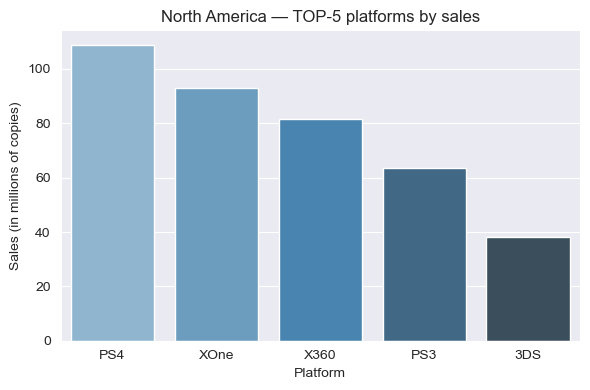

C:\Users\nelli\AppData\Local\Temp\ipykernel_16388\1590612153.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_platforms.index, y=top_platforms.values, palette='Blues_d')


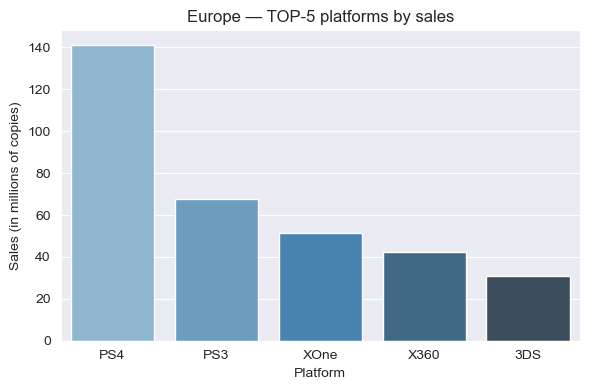

C:\Users\nelli\AppData\Local\Temp\ipykernel_16388\1590612153.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_platforms.index, y=top_platforms.values, palette='Blues_d')


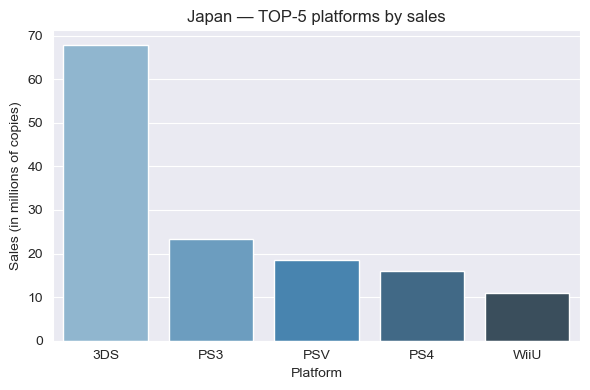

In [192]:

for region, title in zip(regions, titles):
    top_platforms = (
        actual_data
        .groupby('platform')[region]
        .sum()
        .sort_values(ascending=False)
        .head(5)
    )

    plt.figure(figsize=(6, 4))
    sns.barplot(x=top_platforms.index, y=top_platforms.values, palette='Blues_d')
    plt.title(f'{title} — TOP-5 platforms by sales')
    plt.xlabel('Platform')
    plt.ylabel('Sales (in millions of copies)')
    plt.tight_layout()
    plt.show()


**NA (North America):**

- Leaders: X360, PS4, PS3, XOne, 3DS


- Primary preference leans toward Microsoft and Sony consoles.


- Exceptionally strong sales for the X360.



**EU (Europe):**

- Leaders: PS4, PS3, X360, XOne, 3DS


- Stronger preference for Sony—with the PS4 solidly holding the top spot.


- Microsoft is also prominent, but trails behind Sony.


**JP (Japan):**

- Leaders: 3DS, PS3, PS4, PSV, WiiU


- Japanese users strongly favor handheld consoles (3DS, PSV) and Nintendo hardware.


- Xbox platforms are virtually non-existent due to very low market interest.

C:\Users\nelli\AppData\Local\Temp\ipykernel_16388\3160689452.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.index, y=top_genres.values, palette='Greens_d')


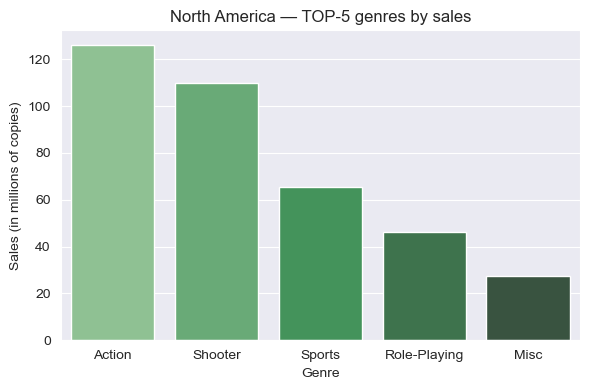

C:\Users\nelli\AppData\Local\Temp\ipykernel_16388\3160689452.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.index, y=top_genres.values, palette='Greens_d')


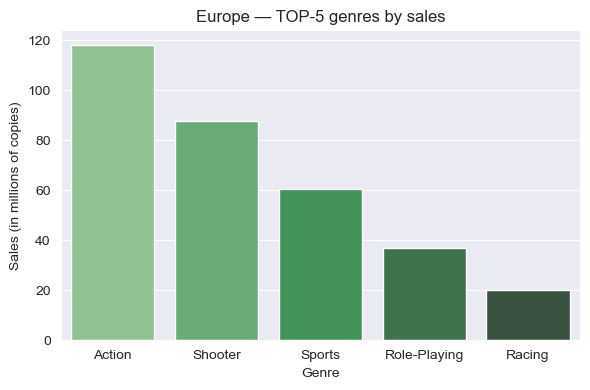

C:\Users\nelli\AppData\Local\Temp\ipykernel_16388\3160689452.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.index, y=top_genres.values, palette='Greens_d')


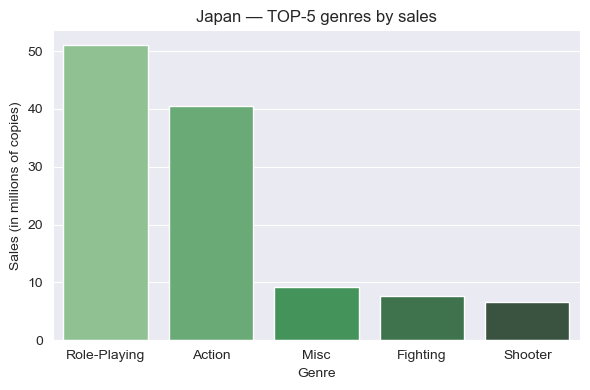

In [193]:
for region, title in zip(regions, titles):
    top_genres = (
        actual_data
        .groupby('genre')[region]
        .sum()
        .sort_values(ascending=False)
        .head(5)
    )

    plt.figure(figsize=(6, 4))
    sns.barplot(x=top_genres.index, y=top_genres.values, palette='Greens_d')
    plt.title(f'{title} — TOP-5 genres by sales')
    plt.xlabel('Genre')
    plt.ylabel('Sales (in millions of copies)')
    plt.tight_layout()
    plt.show()



**NA (North America):**

- Leaders: Action, Shooter, Sports, Role-Playing, Misc


- A strong preference for dynamic and sports games.


**EU (Europe):**

- Similar preferences: Action, Shooter, Sports, Racing, Role-Playing


- Unlike in NA, Racing has higher sales.


**JP (Japan):**

- Drastically different preferences: Role-Playing, Action, Misc, Adventure, Fighting


- RPG is the absolute leader, while Western genres (Shooter, Sports) are almost unrepresented.

C:\Users\nelli\AppData\Local\Temp\ipykernel_16388\3962006082.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=esrb_sales.index.astype(str), y=esrb_sales.values, palette='Reds_d')


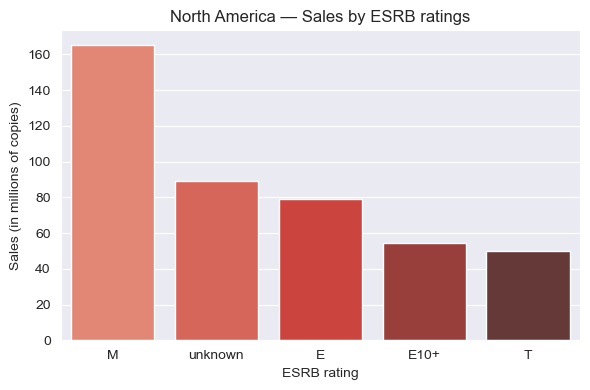

C:\Users\nelli\AppData\Local\Temp\ipykernel_16388\3962006082.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=esrb_sales.index.astype(str), y=esrb_sales.values, palette='Reds_d')


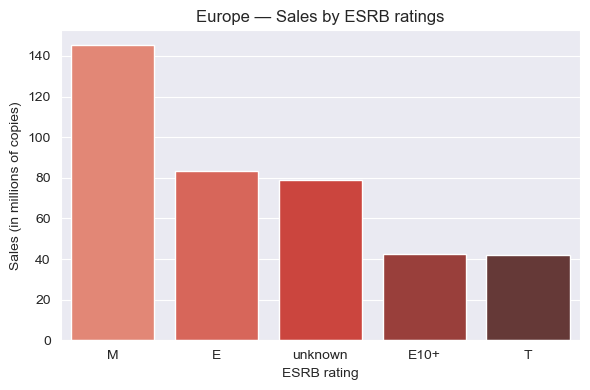

C:\Users\nelli\AppData\Local\Temp\ipykernel_16388\3962006082.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=esrb_sales.index.astype(str), y=esrb_sales.values, palette='Reds_d')


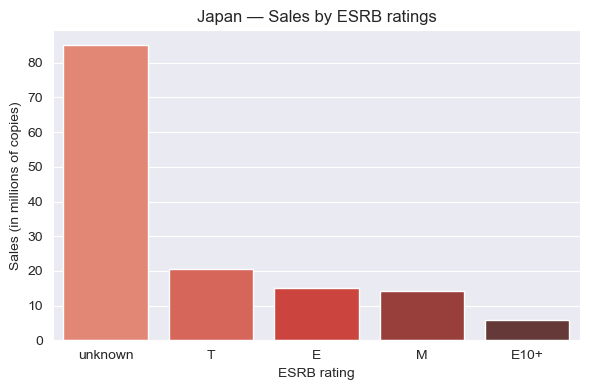

In [194]:


for region, title in zip(regions, titles):
    esrb_sales = (
        actual_data
        .groupby('rating')[region]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(6, 4))
    sns.barplot(x=esrb_sales.index.astype(str), y=esrb_sales.values, palette='Reds_d')
    plt.title(f'{title} — Sales by ESRB ratings')
    plt.xlabel('ESRB rating')
    plt.ylabel('Sales (in millions of copies)')
    plt.tight_layout()
    plt.show()



- In **North America** and **Europe**, the ESRB rating has a noticeable impact on a game's commercial success. The most profitable ratings are "E" (Everyone) and "M" (Mature).


- In **Japan**, the ESRB rating does not play a major role. Sales are driven by local preferences, and many popular titles do not even carry an ESRB rating.


- When planning marketing campaigns for Western markets, age ratings should be factored in, with active promotion targeted toward "E", "T" (Teen), and "M" rated titles.


- For the Japanese market, focus should remain on genre and platform preferences rather than Western ESRB classifications.

**<span style="font-size:24px">Step 5. Checking the hypotheses
</span>**

1. **The average user ratings for the Xbox One and PC platforms are the same.**

- An independent samples t-test is used.


- Null hypothesis (H₀): The average user ratings for Xbox One and PC are the same.

- Alternative hypothesis (H₁): The average user ratings for Xbox One and PC are different.

In [195]:
alpha = 0.05
xone_scores = actual_data[(actual_data['platform'] == 'XOne') & (actual_data['user_score'].notna())]['user_score']
pc_scores = actual_data[(actual_data['platform'] == 'PC') & (actual_data['user_score'].notna())]['user_score']

results = stats.ttest_ind(xone_scores, pc_scores, equal_var=False)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('We reject the null hypothesis: The average ratings are different.')
else:
    print('Failed to reject the null hypothesis: The average ratings are equal.')

p-value: 0.14759594013430463
Failed to reject the null hypothesis: The average ratings are equal.


2. **The average user ratings for the Action and Sports genres are different.**

- An independent samples t-test is used.


- H₀: The average user ratings for the Action and Sports genres are equal.

- H₁: The average user ratings for the Action and Sports genres are different.

In [196]:
action_scores = actual_data[(actual_data['genre'] == 'Action') & (actual_data['user_score'].notna())]['user_score']
sports_scores = actual_data[(actual_data['genre'] == 'Sports') & (actual_data['user_score'].notna())]['user_score']

results_genre = stats.ttest_ind(action_scores, sports_scores, equal_var=False)

print('p-value:', results_genre.pvalue)

if results_genre.pvalue < alpha:
    print('We reject the null hypothesis: The average ratings are different.')
else:
    print('Failed to reject the null hypothesis: The average ratings are equal.')

p-value: 1.4460039700704315e-20
We reject the null hypothesis: The average ratings are different.


**Conclusion:**

1. The average user ratings for the Xbox One and PC platforms are the same.

Null hypothesis (H₀): The average user ratings for Xbox One and PC do not differ.

**<span style="color:green">Based on the t-test results, there is no reason to reject the null hypothesis (the p-value is above the specified significance level); therefore, the differences in average user ratings between these platforms are statistically insignificant.</span>**

2. The average user ratings for the Action and Sports genres differ.

Null hypothesis (H₀): The average user ratings for the action and sports genres are the same.

**<span style="color:green">As a result of the test, the hypothesis was rejected (the p-value is below alpha), meaning the differences in user scores between the action and sports genres are statistically significant.</span>**

**<span style="font-size:24px">Comprehensive conclusion</span>**

**Throughout the project, a comprehensive preprocessing and analysis of video game sales data was conducted to identify key success factors and shape recommendations for promotion in 2017.**


**1. Data Preprocessing and Selection of the Relevant Period**
- Missing values, incorrect data types, and duplicates were identified and handled, ensuring the quality and reliability of the analysis.

- To capture modern trends, the period from 2013 to 2016 was selected, as data from earlier years is either incomplete or outdated due to the rapid evolution of the market.

- **Thus, the research relies on a fresh and relevant sample.**



**2. Analysis of Platforms and Their Lifecycle**
- The platform is a key driver of commercial success.

- The leaders in total and stable sales are the PS4 and Xbox 360.

- The typical platform lifecycle is around 10 years: a sharp growth phase in the first 2–3 years, a sales peak around the middle of the period, followed by a gradual decline.

- **This is crucial to consider when planning game releases and marketing campaigns.**


**3. Impact of Ratings on Sales**
- There is a strong positive correlation between critic ratings and game sales, which is especially noticeable on the PS4 (correlation of ~0.4).

- User ratings have virtually no impact on sales volume (correlation is close to zero).

- **Consequently, professional reviews play a major role in purchasing decisions, which should be factored into PR and marketing strategies.**


**4. Genre Analysis**
- The leaders in total sales and average profitability are the Action, Shooter, and Sports genres.

- Action: 34.3% of all released games and the largest sales volume (around 322 million copies).

- Shooter — fewer games released, but exceptionally high efficiency (sales per title).

- Sports — a stable and profitable genre.

- Less profitable genres — Adventure, Puzzle, Strategy, and Simulation — exhibit low median sales and modest returns.

- **It is recommended to focus on high-efficiency and mass-market genres to maximize profits.**


**5. Regional Preferences**

- **North America and Europe:**

-  Sony and Microsoft consoles dominate.

- Dynamic and sports genres are popular: Action, Shooter, Sports.

- The ESRB age rating noticeably impacts sales — games rated "E", "T", and "M" are the most successful.


- **Japan:**

- Handheld consoles (3DS, PSV) and Nintendo lead the market.

- The primary genre is Role-Playing (RPG); Western genres are almost unrepresented.

- The ESRB rating has practically no influence on sales.

- **These differences must be accounted for when targeting marketing campaigns.**


**6. Hypothesis Testing**

- The average user ratings for the Xbox One and PC platforms do not statistically differ.

- The average ratings for the Action and Sports genres differ — confirming the genre-specific nature of perception and success.

- This highlights the need for an individualized approach to each platform and genre when planning releases and promotional activities."



**<span style="font-size:24px">General Recommendations</span>**

- Focus efforts on promoting games for the PS4 and Xbox 360—the most promising and commercially successful platforms.


- Accentuate Action, Shooter, and Sports genres, as they deliver maximum revenue and reach.


- Utilize critic ratings in marketing materials to build buyer trust.


- When entering Western markets, account for the influence of ESRB ratings and tailor advertising to specific age groups.


- For the Japanese market, focus on handheld platforms and RPG genres.


- When planning new projects and marketing campaigns, rely on recent data from 2013–2016, as they reflect current trends and preferences.
